In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [73]:
# Reading the dataframe.
feat_df = pd.read_csv(r"./Dataset/raw/elliptic_bitcoin_dataset/elliptic_txs_features.csv")
lab_df = pd.read_csv(r"./Dataset/raw/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
# There is a one extra sample in the labels dataset comparing to the features dataset, and therefore we drop it.
lab_df = lab_df.drop(0)

In [74]:
# Concate the features and lebels datasets.
df = pd.concat(
    [feat_df.reset_index(drop=True),
     lab_df[:-1].reset_index(drop=True)],
    axis=1
)
df = df.drop(columns = 'txId', axis = 1)


# Removing samples with unknown labels, and set 1 as illicit and 0 as licit as labels for the rest.
df['class'] = df['class'].astype('string')
df = df[df['class'] != 'unknown']

df['class'] = df['class'].astype('int')
df['class'] = 2 - df['class']             # This guarantees that the illicit (positive) samples are labeled as 1, and licit (negative) 0.

# Creating the training and validation datasets, which are determined via splitting over the "1" column which represents time steps.
df_train = df.loc[df['1'] <= 32]
df_val = df.loc[(df['1'] >= 33) & (df['1'] <= 37)]

# Drop the '1' column, which represents the time progression, as well as the '230425980' column, which is the identification for the samples.
df = df.drop(columns = ['1', '230425980'], axis = 1)



In [75]:
# Printing the absolute number of illicit (1) and licit (0) samples, as well as their portions.
display(df['class'].value_counts(normalize=True))
print(f"The number of illicit samples is {(df['class'] == 1).sum()}, while the number for licit samples is {(df['class'] == 0).sum()}.")

,proportion
class,
0,0.902392
1,0.097608


The number of illicit samples is 4545, while the number for licit samples is 42019.


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
#from sklearn.model_selection import TimeSeriesSplit

# Logistic Regression.
model = LogisticRegression(max_iter= 1000, )


X_train = df_train.drop(columns = 'class', axis = 1)
y_train = df_train['class']

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [77]:
X_val = df_val.drop(columns = 'class', axis = 1)
y_val = df_val['class']
y_pred = model.predict(X_val)

y_scores = model.predict_proba(X_val)[:, 1]   # probability of positive class

The area under the Recall-Precision curve is 0.0749852522094769.
The accuracy is 0.9300466355762825.
The precision is 0.0, while the average precision is 0.07550150657835611.
The recall is 0.0.


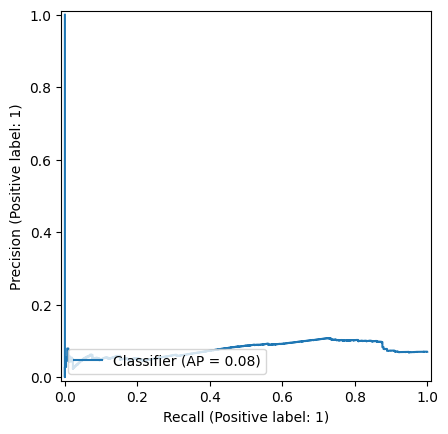

In [78]:
# Plotting the Recall-Precision curve and printing its AUC, as well as the average precision.
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score, precision_score, recall_score, accuracy_score

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
pr_auc = auc(recall, precision)
average_precision = average_precision_score(y_val, y_scores)

accuracy = accuracy_score(y_val, y_pred)
precision_1 = precision_score(y_val, y_pred, zero_division=0)
recall_1 = recall_score(y_val, y_pred)

print(f"The area under the Recall-Precision curve is {pr_auc}.")
print(f"The accuracy is {accuracy}.")
print(f"The precision is {precision_1}, while the average precision is {average_precision}.")
print(f"The recall is {recall_1}.")



PrecisionRecallDisplay.from_predictions(y_val, y_scores)

plt.show()


The area under the ROC curve is 0.5666340716483983.


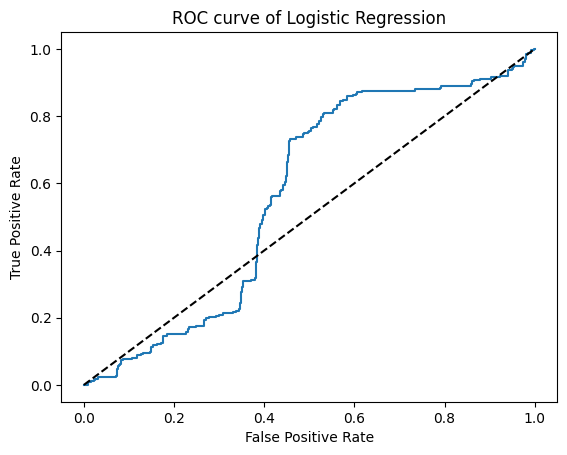

In [79]:
# Plotting the ROC curve, and printing out the area under the curve.
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_scores)

ft_auc = auc(fpr, tpr)
print(f"The area under the ROC curve is {ft_auc}.")


plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic Regression')

plt.show()

In [80]:
# Feature importance list.

feature_names = X_train.columns

# Binary classification
coefficients = model.coef_[0]  # shape: (n_features,)

# Multi-class: model.coef_ has shape (n_classes, n_features)
# coefficients = model.coef_  # one row per class

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_importance': np.abs(coefficients)
}).sort_values('abs_importance', ascending=False).head(10)

print(importance_df)

                 feature   coefficient  abs_importance
0              230425980 -7.483493e-09    7.483493e-09
1                      1 -7.005390e-16    7.005390e-16
54  -0.48834041329936734 -4.658641e-16    4.658641e-16
55  -0.23255262057859216 -4.140280e-16    4.140280e-16
56  -0.46755439410398614 -3.788533e-16    3.788533e-16
90  -0.15973245222462992 -3.428287e-16    3.428287e-16
91  0.034038660711490365 -3.387625e-16    3.387625e-16
61  -0.16312596586207964 -3.106786e-16    3.106786e-16
67  -0.16311462864045503 -3.106736e-16    3.106736e-16
66   -0.1728840699195216 -3.053672e-16    3.053672e-16


In [81]:
# Training and tuning Logistic Regression with L-2 regularization, penaltizing non-effective features. (L-1 appears to lead to severe divergence issues.)
# We use a random search over [1, 10] partitioned into 20 sub-intervals for the optimal hyperparameter 'C' in L2 logistic regression,
# recall that larger 'C' value leads to milder regularization.

from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Building a threefold for hyper-parameter tuning.
kf = KFold(n_splits=3, shuffle = True, random_state=42)

# Building searching parameter grids.
param_grid = [
    {
        'log_reg__penalty': ['l2'],
        'log_reg__C': np.linspace(1, 10, 20)
    }
    ]

# Building model pipeline.
steps_1 = [("scaler", StandardScaler()),
         ("log_reg", LogisticRegression(
        max_iter=1000))]
pipeline_1 = Pipeline(steps_1)

# Randomized search.
LR_cv = RandomizedSearchCV(pipeline_1,
              param_grid,
              cv = kf,
              scoring = 'average_precision',
              n_jobs = -1
              )
LR_cv.fit(X_train, y_train)

print("Tuned parameters: {}".format(LR_cv.best_params_))
print("Tuned average precision score: {}".format(LR_cv.best_score_))

Tuned parameters: {'log_reg__penalty': 'l2', 'log_reg__C': np.float64(8.105263157894736)}
Tuned average precision score: 0.9030010327474424


The tuned accuracy is 0.8954030646235843.
The tuned precision is 0.39166666666666666.
The tuned recall is 0.8952380952380953.


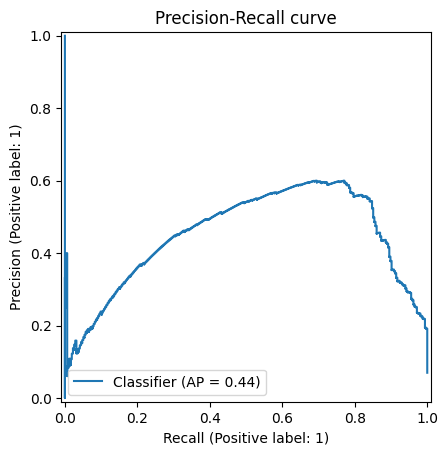

In [82]:
# Tuned Recall-Precision curve.
y_pred = LR_cv.predict(X_val)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
accuracy = accuracy_score(y_val, y_pred)

print(f"The tuned accuracy is {accuracy}.")
print(f"The tuned precision is {precision}.")
print(f"The tuned recall is {recall}.")

y_scores_1 = LR_cv.predict_proba(X_val)[:, 1]
PrecisionRecallDisplay.from_predictions(y_val, y_scores_1)

plt.title('Precision-Recall curve')
plt.show()

The area under the un-tuned ROC curve is 0.5666340716483983.
The area under the tuned ROC curve is 0.950294113188096.


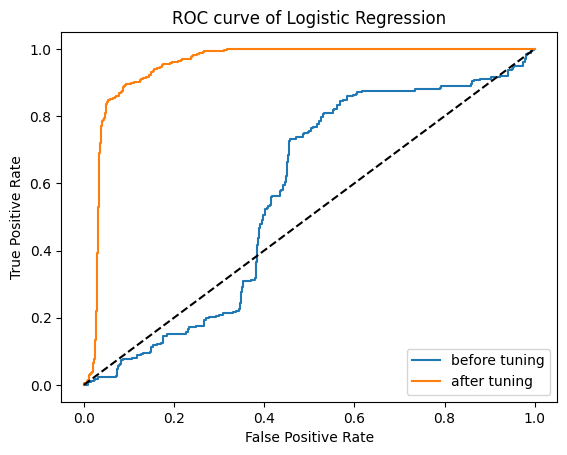

In [83]:
# Tuned ROC curve.
fpr_1, tpr_1, thresholds_1 = roc_curve(y_val, y_scores_1)

ft_auc_1 = auc(fpr_1, tpr_1)
print(f"The area under the un-tuned ROC curve is {ft_auc}.")
print(f"The area under the tuned ROC curve is {ft_auc_1}.")


plt.plot(fpr, tpr, label = 'before tuning')
plt.plot(fpr_1, tpr_1, label = 'after tuning')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic Regression')

plt.legend()
plt.show()